<a href="https://colab.research.google.com/github/w-b-d/Ml-Project/blob/will%2Fdev/notebook/training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Breast Cancer Detection**
**Team Members:**  
- Anghel Carrillo  
- Kristopher Church  
- Brianna Magallon  
- William Brady-Diaz  

**Date:** December 2025  


In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import cv2
import glob
import random
from os import listdir
from sklearn.metrics import classification_report
import tensorflow as tf
import keras.utils as image
import keras
from sklearn.model_selection import train_test_split
import pandas as pd
import os
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Extract IDC Breast Cancer Dataset into Colab Runtime

In [3]:
zip_path = "/content/drive/MyDrive/LeBromide/data/IDC_regular_ps50_idx5.zip"
!unzip -q "$zip_path" -d data/
print("Dataset extracted into /content/data/")

Dataset extracted into /content/data/


Number of images found: 277524
Example image: data/IDC_regular_ps50_idx5/12955/0/12955_idx5_x351_y651_class0.png


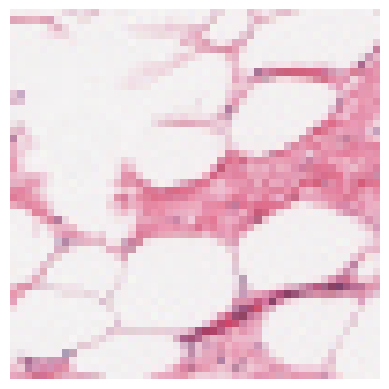

In [6]:

image_paths = glob.glob("data/IDC_regular_ps50_idx5/*/*/*.png")
print("Number of images found:", len(image_paths))


random_path = random.choice(image_paths)
print("Example image:", random_path)

img = cv2.imread(random_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.axis("off")
plt.show()

*italicized text*## ** Baseline Model **

> Add blockquote




In [10]:

data = []

for path in image_paths:

    label = os.path.basename(os.path.dirname(path))
    data.append([path, int(label)])

df = pd.DataFrame(data, columns=["filepath", "label"])


                                                 filepath  label
0       data/IDC_regular_ps50_idx5/10300/1/10300_idx5_...      1
1       data/IDC_regular_ps50_idx5/10300/1/10300_idx5_...      1
2       data/IDC_regular_ps50_idx5/10300/1/10300_idx5_...      1
3       data/IDC_regular_ps50_idx5/10300/1/10300_idx5_...      1
4       data/IDC_regular_ps50_idx5/10300/1/10300_idx5_...      1
...                                                   ...    ...
277095  data/IDC_regular_ps50_idx5/12896/1/12896_idx5_...      1
277096  data/IDC_regular_ps50_idx5/12896/1/12896_idx5_...      1
277097  data/IDC_regular_ps50_idx5/12896/1/12896_idx5_...      1
277098  data/IDC_regular_ps50_idx5/12896/1/12896_idx5_...      1
277099  data/IDC_regular_ps50_idx5/12896/1/12896_idx5_...      1

[78786 rows x 2 columns]


Initialize Dataset and Apply Transforms

In [18]:


train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)

print(len(train_df), len(test_df))
train_df, val_df = train_test_split(
    train_df,
    test_size=0.2,
    random_state=42,
    stratify=train_df['label']
)

print(len(train_df), len(val_df), len(test_df))
train_df['label'] = train_df['label'].astype(str)
val_df['label'] = val_df['label'].astype(str)
test_df['label'] = test_df['label'].astype(str)

222019 55505
177615 44404 55505


Train/Validation Split and DataLoaders

> Add blockquote



In [19]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

In [20]:
batch_size = 32
target_size = (50, 50)

train_gen = train_datagen.flow_from_dataframe(
    train_df,
    x_col='filepath',
    y_col='label',
    target_size=target_size,
    color_mode='rgb',
    class_mode='binary',
    batch_size=batch_size,
    shuffle=True
)

val_gen = val_datagen.flow_from_dataframe(
    val_df,
    x_col='filepath',
    y_col='label',
    target_size=target_size,
    color_mode='rgb',
    class_mode='binary',
    batch_size=batch_size,
    shuffle=False
)

test_gen = test_datagen.flow_from_dataframe(
    test_df,
    x_col='filepath',
    y_col='label',
    target_size=target_size,
    color_mode='rgb',
    class_mode='binary',
    batch_size=batch_size,
    shuffle=False
)

Found 177615 validated image filenames belonging to 2 classes.
Found 44404 validated image filenames belonging to 2 classes.
Found 55505 validated image filenames belonging to 2 classes.


In [22]:
input_shape = (50, 50, 3)
batch_size = 128
kernel_size = 3
filters = 64
dropout = 0.3

In [27]:
inputs = Input(shape=input_shape)
y = Conv2D(filters=filters,
           kernel_size=kernel_size,
           activation='relu')(inputs)
y = MaxPooling2D()(y)
y = Conv2D(filters=filters,
           kernel_size=kernel_size,
           activation='relu')(y)
y = MaxPooling2D()(y)
y = Conv2D(filters=filters,
           kernel_size=kernel_size,
           activation='relu')(y)

y = Flatten()(y)

y = Dropout(dropout)(y)
outputs = Dense(1, activation='sigmoid')(y)


model = Model(inputs=inputs, outputs=outputs)

In [31]:
print(model.summary())

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 50, 50, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 48, 48, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 22, 22, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 11, 11, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 9, 9, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 5184)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 5184)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         5,185 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 80,833 (315.75 KB)

 Trainable params: 80,833 (315.75 KB)

 Non-trainable params: 0 (0.00 B)

None


In [32]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
model.fit(x_train,
          y_train,
          validation_data=(x_test, y_test),
          epochs=20,
          batch_size=batch_size)


score = model.evaluate(x_test,
                       y_test,
                       batch_size=batch_size,
                       verbose=0)
print("\nTest accuracy: %.1f%%" % (100.0 * score[1]))

In [35]:
EPOCHS = 1

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS
)

5551/5551 ━━━━━━━━━━━━━━━━━━━━ 1364s 246ms/step - accuracy: 0.8486 - loss: 0.3568 - val_accuracy: 0.8569 - val_loss: 0.3345
